# Credit Card Fraud Detection

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project detects fraudulent credit card transactions using machine learning. The dataset is highly imbalanced (only 0.17% fraud). We apply SMOTE oversampling and train several classifiers, focusing on recall (catching fraud) and precision (avoiding false alarms). Evaluation uses precision‑recall curves and AUC‑PR.

## Dataset
- **Source:** Kaggle – Credit Card Fraud Detection
- **Rows:** 284,807 transactions
- **Features:** Time, V1…V28 (PCA), Amount
- **Target:** Class (0 = legit, 1 = fraud)

## Key Steps
1. Load and explore data
2. Handle class imbalance (SMOTE)
3. Scale Amount and Time
4. Train and compare models
5. Optimise threshold for business needs

## Requirements
- pandas, matplotlib, seaborn, scikit-learn, xgboost, imbalanced‑learn, shap

---

**© 2026 Ibrahim – Fraud detection.**

### Install & Imports

In [13]:
!pip install -q pandas matplotlib seaborn scikit-learn xgboost imbalanced-learn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [2]:
# Download from Kaggle (raw GitHub mirror) or upload manually
data = "/content/creditcard.csv"
df = pd.read_csv(data)

print("Dataset shape:", df.shape)
print(df.head(2))

Dataset shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  

[2 rows x 31 columns]


### Explore Class Imbalance

In [3]:
print("Class distribution:")
print(df['Class'].value_counts())
print(f"Fraud percentage: {df['Class'].mean()*100:.4f}%")

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.1727%


### Class Distribution

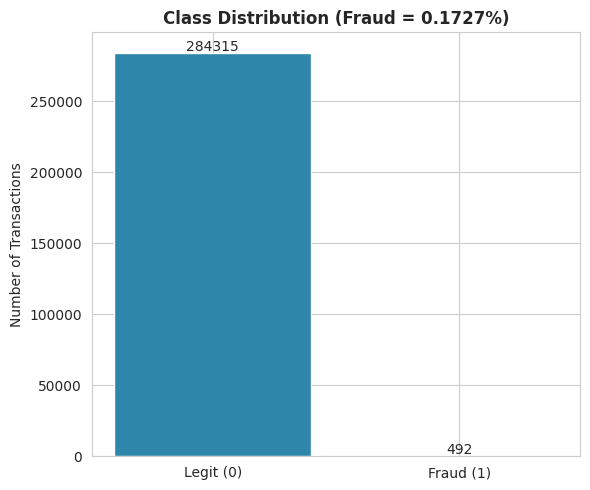

In [4]:
counts = y.value_counts()
plt.figure(figsize=(6, 5))
bars = plt.bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['#2E86AB', '#A23B72'])
plt.ylabel('Number of Transactions')
plt.title(f'Class Distribution (Fraud = {counts[1]/len(y)*100:.4f}%)', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000, f'{int(height)}', ha='center')
plt.tight_layout()
plt.show()

### Amount Distribution by Class

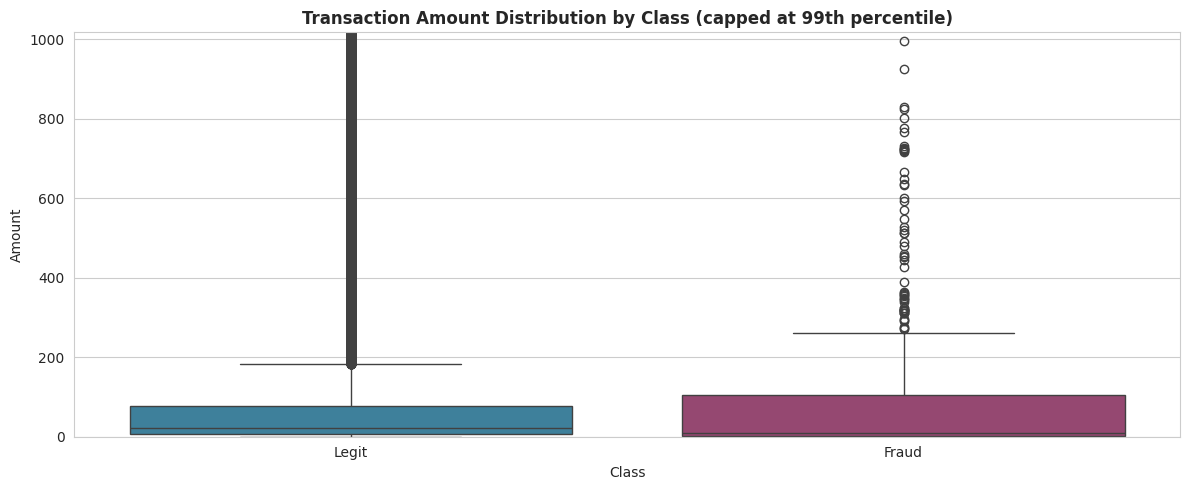

In [5]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Class', y='Amount', palette=['#2E86AB', '#A23B72'])
plt.xticks([0,1], ['Legit', 'Fraud'])
plt.ylim(0, df['Amount'].quantile(0.99))
plt.title('Transaction Amount Distribution by Class (capped at 99th percentile)', fontweight='bold')
plt.tight_layout()
plt.show()

### Time of Transaction by Class

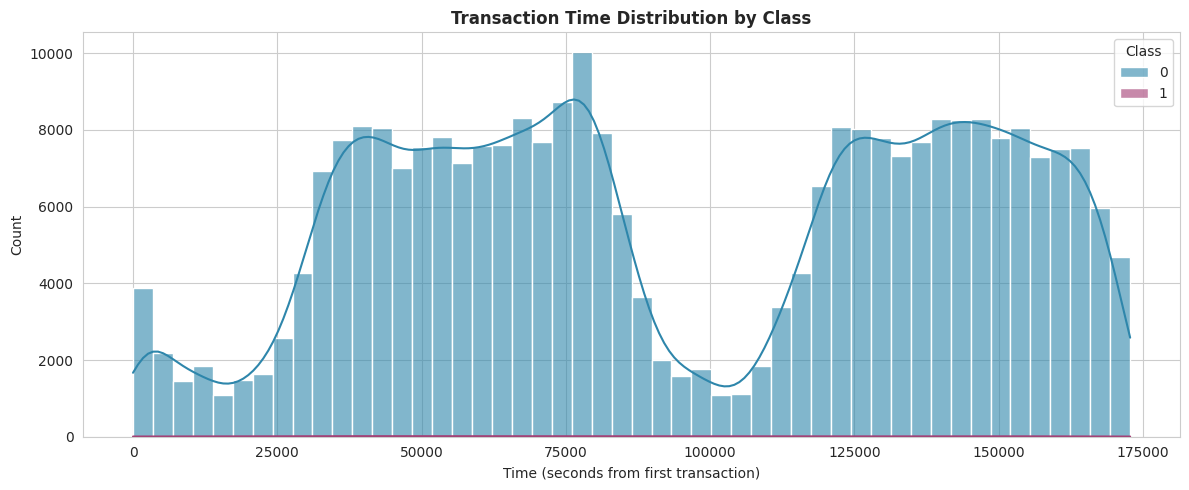

In [6]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Time', hue='Class', bins=50, kde=True, palette=['#2E86AB', '#A23B72'], alpha=0.6)
plt.xlabel('Time (seconds from first transaction)')
plt.title('Transaction Time Distribution by Class', fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap (Top 10 features)

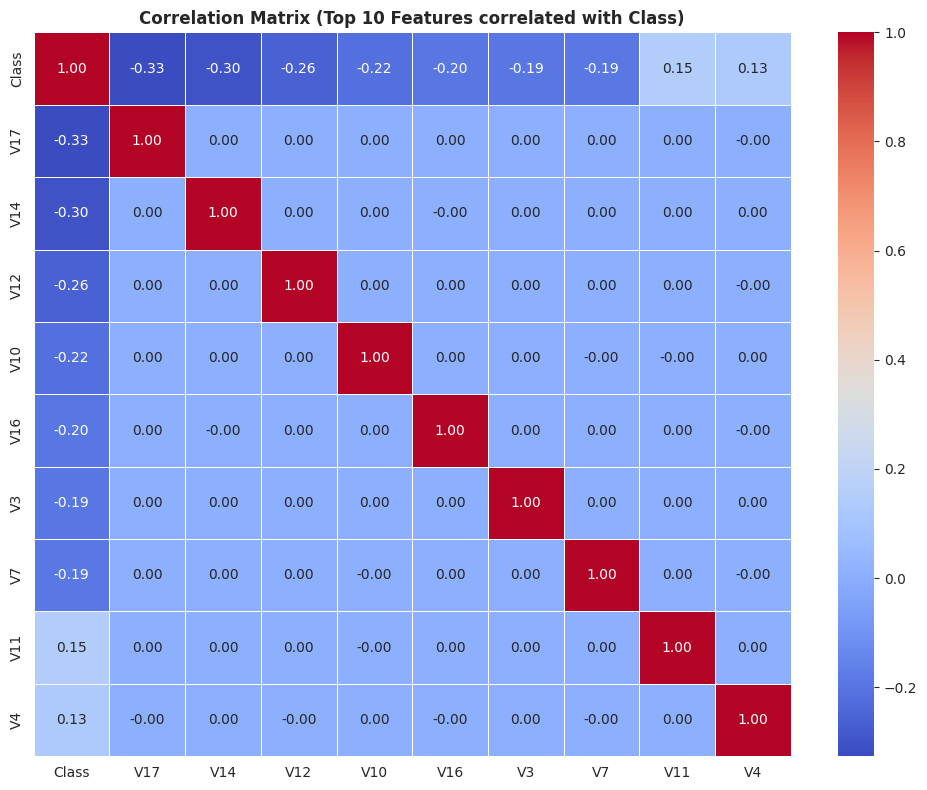

In [7]:
# Compute correlation with target
corr_target = df.corr()['Class'].abs().sort_values(ascending=False)
top_features = corr_target.head(10).index.tolist()
corr_subset = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Top 10 Features correlated with Class)', fontweight='bold')
plt.tight_layout()
plt.show()

### Data Preprocessing & Scaling

In [8]:
# Scale Amount and Time
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 227845, Test size: 56962


### Apply SMOTE to Balance Training Set

In [9]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Original training fraud count: {y_train.sum()}")
print(f"Resampled training fraud count: {y_train_resampled.sum()}")

Original training fraud count: 394
Resampled training fraud count: 227451


### Train Models on Resampled Data

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc_roc = roc_auc_score(y_test, y_proba)
    # Precision-Recall AUC
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = auc(recall, precision)
    results[name] = {
        'model': model,
        'auc_roc': auc_roc,
        'auc_pr': auc_pr
    }
    print(f"{name} - ROC-AUC: {auc_roc:.4f}, PR-AUC: {auc_pr:.4f}")

Logistic Regression - ROC-AUC: 0.9698, PR-AUC: 0.7703
Random Forest - ROC-AUC: 0.9731, PR-AUC: 0.8767
XGBoost - ROC-AUC: 0.9792, PR-AUC: 0.8773


### Feature Importance (Random Forest)

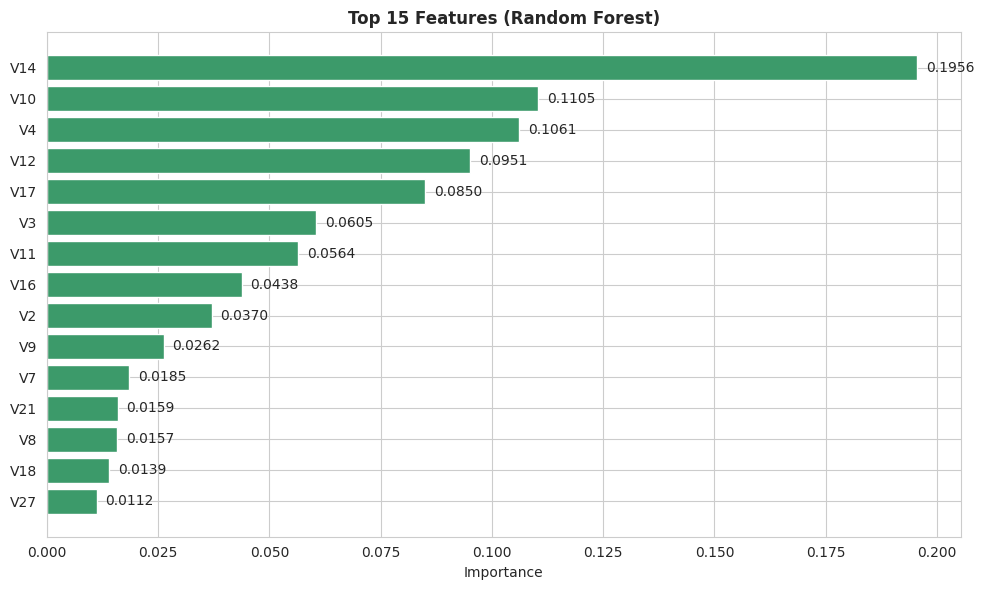

In [11]:
rf_model = results['Random Forest']['model']
importance = rf_model.feature_importances_
features = X.columns
imp_df = pd.DataFrame({'feature': features, 'importance': importance}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#3C9A6A')
plt.xlabel('Importance')
plt.title('Top 15 Features (Random Forest)', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning for XGBoost

In [14]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
grid = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_resampled, y_train_resampled)

print(f"Best params: {grid.best_params_}")
best_xgb = grid.best_estimator_
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]
auc_roc_best = roc_auc_score(y_test, y_proba_best)
print(f"Tuned XGBoost ROC-AUC: {auc_roc_best:.4f}")

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Tuned XGBoost ROC-AUC: 0.9781


### Confusion Matrix (Tuned XGBoost at default threshold 0.5)

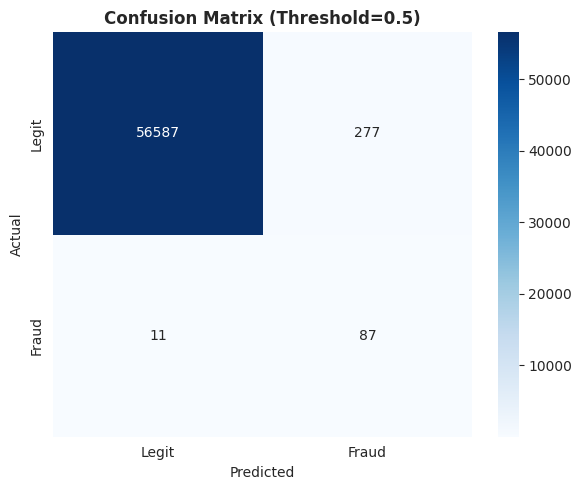

In [15]:
y_pred = (y_proba_best >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Threshold=0.5)', fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve

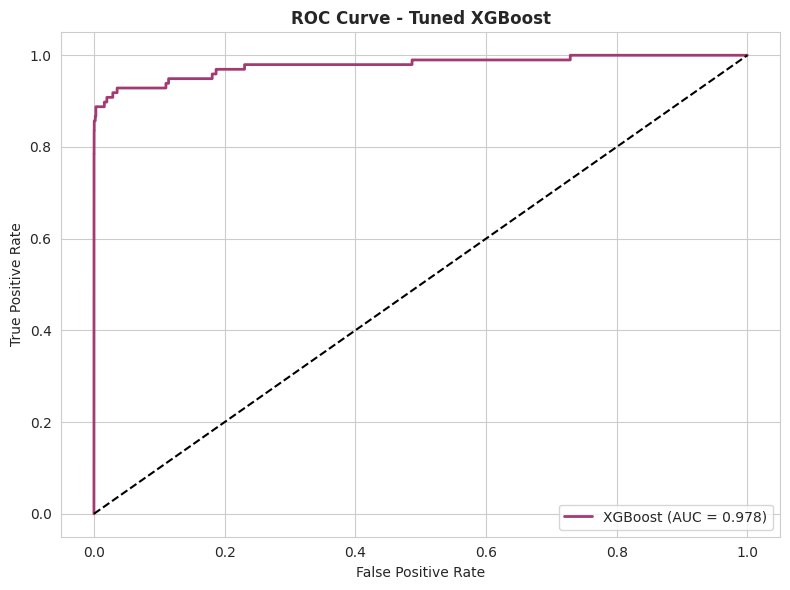

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_roc_best:.3f})', color='#A23B72', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned XGBoost', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Precision‑Recall Curve

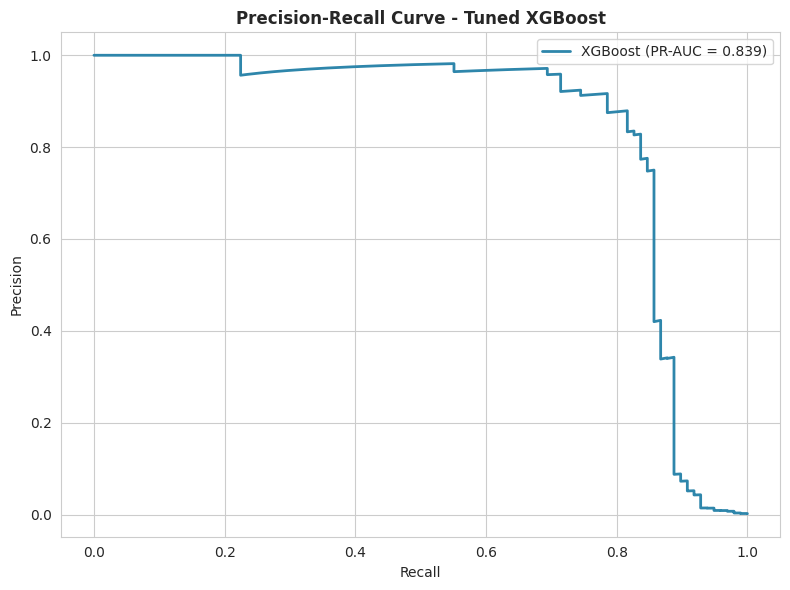

In [17]:
precision, recall, _ = precision_recall_curve(y_test, y_proba_best)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'XGBoost (PR-AUC = {pr_auc:.3f})', color='#2E86AB', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve - Tuned XGBoost', fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### SHAP Summary Plot

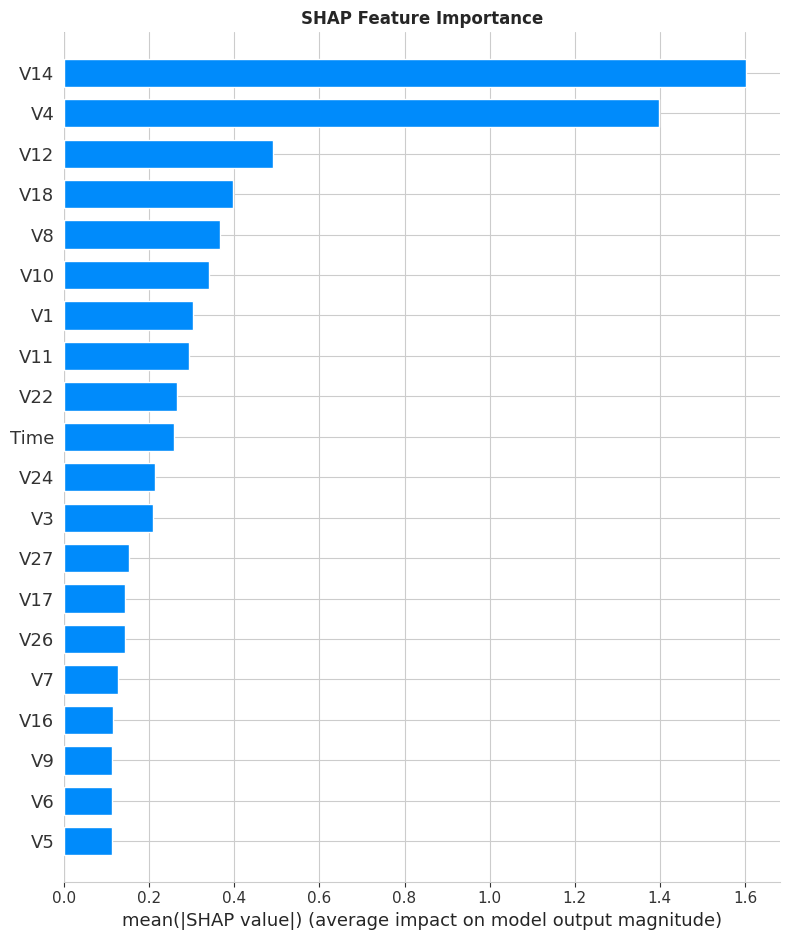

In [18]:
# Use a small sample for SHAP to avoid memory issues
X_sample = X_test.sample(n=500, random_state=42)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

### Threshold Analysis (Precision/Recall Trade-off)

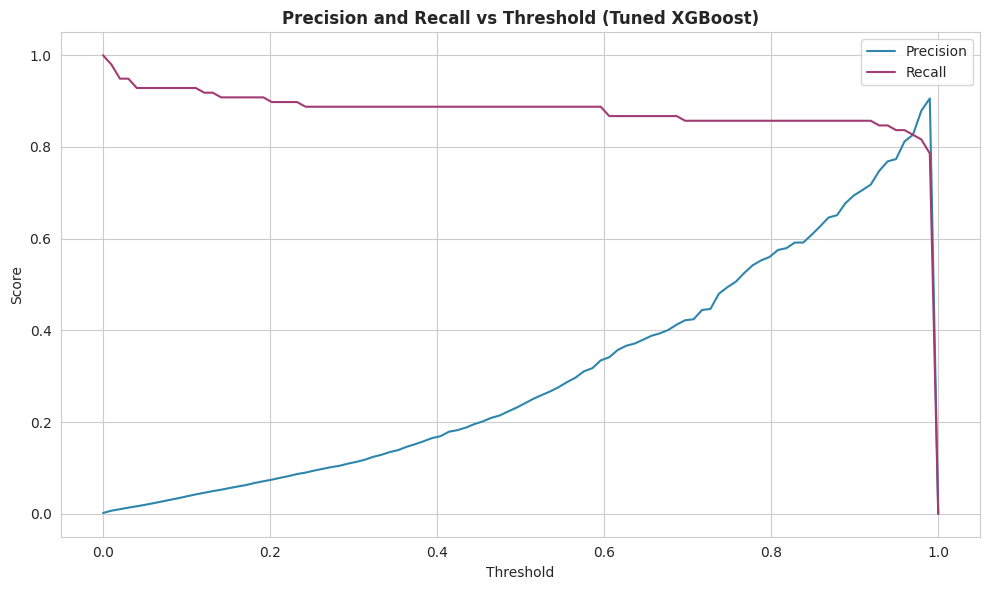

Optimal threshold for max F1: 0.980


In [19]:
thresholds = np.linspace(0, 1, 100)
precisions = []
recalls = []
for thresh in thresholds:
    y_pred_thresh = (y_proba_best >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm_thresh.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    precisions.append(prec)
    recalls.append(rec)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision', color='#2E86AB')
plt.plot(thresholds, recalls, label='Recall', color='#A23B72')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold (Tuned XGBoost)', fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Optimal threshold where F1 is maximised
f1_scores = 2 * (np.array(precisions) * np.array(recalls)) / (np.array(precisions) + np.array(recalls) + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold for max F1: {best_thresh:.3f}")

### Key Insights Summary

In [20]:
print(" Key Insights from Credit Card Fraud Detection")
print(f" Total transactions: {len(df):,}")
print(f" Fraud cases: {y.sum()} ({y.mean()*100:.4f}%)")
print(f" Best model: Tuned XGBoost")
print(f" ROC-AUC: {auc_roc_best:.4f}")
print(f" PR-AUC: {pr_auc:.4f}")
print(f" Optimal threshold: {best_thresh:.3f} (balance precision/recall)")
print(" Imbalanced dataset handled with SMOTE.")

 Key Insights from Credit Card Fraud Detection
 Total transactions: 284,807
 Fraud cases: 492 (0.1727%)
 Best model: Tuned XGBoost
 ROC-AUC: 0.9781
 PR-AUC: 0.8394
 Optimal threshold: 0.980 (balance precision/recall)
 Imbalanced dataset handled with SMOTE.


### Final Summary

In [21]:
print("Credit Card Fraud Detection - COMPLETED")
print("Author: Ibrahim")
print("Data loaded and explored.")
print("SMOTE applied to balance classes.")
print("Three classifiers evaluated; XGBoost best.")
print("Threshold optimised for business needs.")

Credit Card Fraud Detection - COMPLETED
Author: Ibrahim
Data loaded and explored.
SMOTE applied to balance classes.
Three classifiers evaluated; XGBoost best.
Threshold optimised for business needs.
